In [1]:
# @title Imports
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from popy.config import PROJECT_PATH_LOCAL, COLORS

/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-6snlhcny because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def load_res():
    # show bic and LPT values
    dfs = []
    for monkey in ['ka', 'po']:#:, 'yu_sham', 'yu_DCZ']:
        # load behavior data
        floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', 'fitting', f'simulation_results_{monkey}.csv')
        res_temp = pd.read_csv(floc)

        # add monkey name to the dataframe and move to first col
        res_temp['monkey'] = monkey
        

        dfs.append(res_temp)
    return pd.concat(dfs, ignore_index=True)

def plot_res(res_all, paper_format=False):
    # Set font size and figure size
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        w, h = 4, 4
    else:
        plt.rcParams.update({'font.size': 8})
        w, h = ((12/5)/3)*(len(res_all)/2), 5/1

    # Define the modes and figure
    modes = ['LPT_CV']
    fig, axes = plt.subplots(2, 1, figsize=(w/2.54, h/2.54), gridspec_kw={'hspace': 0.3})

    # Get unique values
    models = res_all.loc[res_all['monkey'] != 'yu_DCZ', 'Model'].unique()
    monkeys = res_all.loc[res_all['monkey'] != 'yu_DCZ', 'monkey'].unique()

    # Iterate over the modes and plot
    for mode_idx, mode in enumerate(modes):
        # Set up positions
        x = np.arange(len(models))
        width = 0.65  # Width of bars

        for i, monkey in enumerate(monkeys):
            ax = axes[i]  # Use separate subplot for each monkey
            
            data = res_all.loc[(res_all['monkey'] == monkey) & (res_all['monkey'] != 'yu_DCZ')]
            values = [data.loc[data['Model'] == model, mode].iloc[0] if len(data.loc[data['Model'] == model]) > 0 else 0 for model in models]
            
            # Create bars with model-based coloring
            for j, (model, value) in enumerate(zip(models, values)):
                hatch = None
                if model.split()[0] == 'Standard':
                    # replace  what comes after with RL
                    color = COLORS['Standard RL']
                    if (not model == 'Standard RL - stickiness' and not paper_format) or (paper_format and not model == 'Standard RL'):
                        hatch = '///'  # Dashed filling pattern
                elif model.split()[0] == 'Inferential':
                    color = COLORS['Inferential RL']
                    if (not model == 'Inferential RL - stickiness' and not paper_format) or (paper_format and not model == 'Inferential RL'):
                        hatch = '///'  # Dashed filling pattern
                elif model.split()[0] == 'Foraging':
                    color = COLORS['Foraging']
                    if not len(model.split(" ")) == 1:
                        hatch = '///'  # Dashed filling pattern
                else:
                    color = COLORS.get(model, 'grey')
                    hatch = None
                alpha = 0.8
                
                
                bar = ax.bar(x[j], value, width, 
                    color=color, hatch=hatch,
                    edgecolor='black', linewidth=0.5, alpha=alpha)
                
                # Set hatch color to grey for RL-s models
                if model.split()[-1] == 'RL-s':
                    import matplotlib as mpl
                    mpl.rcParams['hatch.color'] = 'grey'
            
            
            for model, value in zip(models, values):
                print(f"{mode}: {monkey} {model}: {value:.2f}")

            # add monkey name (capitalized) as title, y axis a bit lower
            ax.set_title(monkey.upper(), fontsize=10, y=.85)

            # Configure axes
            ax.set_ylim(0.3, 0.85)
            ax.set_yticks(np.arange(0.3, 0.9, 0.2))
            ax.set_ylabel('LPT', fontsize=8)
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            ax.grid(axis='y', linestyle='dotted', alpha=0.5, zorder=0)

            # Only add x-axis labels to bottom plot
            if i == len(monkeys) - 1:  # Bottom plot
                ax.set_xticks(x)
                if paper_format:
                    ax.set_xticklabels(models, rotation=45, horizontalalignment='right')
                else:
                    ax.set_xticklabels(models, rotation=-90, horizontalalignment='center')
            else:  # Top plot
                ax.set_xticks(x)
                ax.set_xticklabels([])  # Remove x-axis labels from top plot

    return fig, axes

res_all = load_res()
#res_all = res_all.sort_values(['Model', 'monkey'])

res_all = res_all.sort_values('Model')
res_all

,Model,epsilon,alpha,alpha_unchosen,beta,V0,forgetting_rate,forgetting_threshold,stickiness_bias,b2,...,BIC_std,LPT_CV,LPT_std,LL_best,BIC_best,LPT_best,Reward rate,Proba best,alpha_threshold,monkey
25,Foraging,NaN,0.301837,NaN,6.968843,0.178251,NaN,NaN,NaN,NaN,...,306.549987,0.595746,0.039285,-7830.636466,15690.151188,0.596484,0.51466,0.63288,NaN,po
6,Foraging,NaN,0.403461,NaN,10.743618,0.121124,NaN,NaN,NaN,NaN,...,117.058119,0.787503,0.017931,-5666.449537,11363.138951,0.788607,0.54781,0.71869,NaN,ka
31,Foraging - abandoned bias,NaN,0.317311,NaN,5.928644,0.108388,NaN,NaN,NaN,NaN,...,308.388603,0.595720,0.039265,-7866.166657,15780.463743,0.595087,0.51774,0.63436,NaN,po
7,Foraging - abandoned bias,NaN,0.379934,NaN,11.100396,0.131046,NaN,NaN,NaN,NaN,...,117.667341,0.786902,0.017939,-5676.827432,11404.054657,0.788264,0.54779,0.72091,NaN,ka
24,Foraging - abandoned bias + spatial bias,NaN,0.316672,NaN,6.532717,0.158220,NaN,NaN,NaN,0.691090,...,305.438814,0.595455,0.038955,-7834.315177,15726.386869,0.596339,0.50416,0.60011,NaN,po
13,Foraging - abandoned bias + spatial bias,NaN,0.405176,NaN,10.967922,0.127105,NaN,NaN,NaN,-3.607682,...,121.052875,0.786089,0.018646,-5668.390823,11397.261399,0.788543,0.49657,0.57521,NaN,ka
29,Foraging - adaptive threshold,NaN,0.335737,NaN,6.773412,0.158426,NaN,NaN,NaN,NaN,...,300.865560,0.596115,0.038498,-7845.019814,15728.543972,0.595918,0.52410,0.65009,0.00000,po
14,Foraging - adaptive threshold,NaN,0.457614,NaN,9.094214,0.050000,NaN,NaN,NaN,NaN,...,118.558237,0.786237,0.017479,-5726.348352,11493.016539,0.786630,0.54296,0.70340,0.00036,ka
23,Foraging - no reset,NaN,0.438418,NaN,5.432612,0.167679,NaN,NaN,NaN,NaN,...,321.866504,0.579654,0.040132,-8253.556660,16535.991577,0.580068,0.49715,0.57755,NaN,po
5,Foraging - no reset,NaN,0.430530,NaN,11.014925,0.130596,NaN,NaN,NaN,NaN,...,127.347576,0.783186,0.020132,-5802.958057,11636.155990,0.784108,0.54748,0.71576,NaN,ka


In [3]:
# sort res_all 'Model' column by the order of keys in MODELS 

from run_model_optimizing import MODELS

model_order = list(MODELS.keys())
present_models = res_all["Model"].dropna().astype(str).unique().tolist()

# Keep only models that are present, then append unexpected ones
ordered_present = [m for m in model_order if m in present_models]
extra_present = [m for m in present_models if m not in ordered_present]
final_order = ordered_present + extra_present

res_all = (
    res_all.assign(
        Model=pd.Categorical(res_all["Model"], categories=final_order, ordered=True)
    )
    .sort_values("Model")
    .reset_index(drop=True)
)

res_all

,Model,epsilon,alpha,alpha_unchosen,beta,V0,forgetting_rate,forgetting_threshold,stickiness_bias,b2,...,BIC_std,LPT_CV,LPT_std,LL_best,BIC_best,LPT_best,Reward rate,Proba best,alpha_threshold,monkey
0,Repeating agent,0.336866,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,364.255861,0.503349,0.035551,-10380.125536,20769.877157,0.504125,0.40164,0.33623,NaN,po
1,Repeating agent,0.152041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,215.676690,0.672310,0.019331,-9427.824431,18865.728821,0.673592,0.40305,0.33406,NaN,ka
2,WSLS,0.524388,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,439.247167,0.401421,0.005079,-21771.342676,43552.765310,0.401534,0.43364,0.40997,NaN,ka
3,WSLS,0.548340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,507.990329,0.390385,0.009555,-14263.920739,28537.467564,0.390158,0.43210,0.40596,NaN,po
4,Standard RL,NaN,0.542161,NaN,7.819426,NaN,NaN,NaN,NaN,NaN,...,208.509180,0.681845,0.034398,-9067.786787,18155.733491,0.683833,0.54226,0.70062,NaN,ka
5,Standard RL,NaN,0.385290,NaN,3.876945,NaN,NaN,NaN,NaN,NaN,...,493.178772,0.466522,0.038768,-11595.134860,23209.521892,0.465286,0.50541,0.60614,NaN,po
6,Standard RL - stickiness,NaN,0.357619,NaN,2.569987,NaN,NaN,NaN,1.514311,NaN,...,348.543373,0.515317,0.046861,-9177.123291,18383.124840,0.545774,0.49007,0.57118,NaN,po
7,Standard RL - stickiness,NaN,0.763787,NaN,4.756307,NaN,NaN,NaN,1.862007,NaN,...,158.016677,0.742084,0.023474,-7208.093414,14446.426704,0.739265,0.49648,0.58465,NaN,ka
8,Standard RL - forgetting,NaN,0.425657,NaN,10.067737,NaN,0.515179,0.066333,NaN,NaN,...,117.652229,0.783684,0.019515,-5954.180236,11948.680306,0.779154,0.55164,0.72886,NaN,ka
9,Standard RL - forgetting,NaN,0.313146,NaN,6.823602,NaN,0.848719,0.057785,NaN,NaN,...,290.569329,0.602297,0.037318,-7695.346269,15429.196882,0.601833,0.52196,0.64989,NaN,po


In [4]:
# remove Repeating agent and HSMM
res_all = res_all[~res_all['Model'].isin(['Repeating agent', 'HSMM'])]

LPT_CV: ka WSLS: 0.40
LPT_CV: ka Standard RL: 0.68
LPT_CV: ka Standard RL - stickiness: 0.74
LPT_CV: ka Standard RL - forgetting: 0.78
LPT_CV: ka Standard RL - stickiness + forgetting: 0.79
LPT_CV: ka Inferential RL: 0.58
LPT_CV: ka Inferential RL - stickiness: 0.75
LPT_CV: ka Inferential RL - stickiness + spatial bias: 0.75
LPT_CV: ka Inferential RL - stickiness + multiple alphas: 0.75
LPT_CV: ka Foraging - no reset: 0.78
LPT_CV: ka Foraging: 0.79
LPT_CV: ka Foraging - abandoned bias: 0.79
LPT_CV: ka Foraging - abandoned bias + spatial bias: 0.79
LPT_CV: ka Foraging - adaptive threshold: 0.79
LPT_CV: po WSLS: 0.39
LPT_CV: po Standard RL: 0.47
LPT_CV: po Standard RL - stickiness: 0.52
LPT_CV: po Standard RL - forgetting: 0.60
LPT_CV: po Standard RL - stickiness + forgetting: 0.60
LPT_CV: po Inferential RL: 0.44
LPT_CV: po Inferential RL - stickiness: 0.56
LPT_CV: po Inferential RL - stickiness + spatial bias: 0.56
LPT_CV: po Inferential RL - stickiness + multiple alphas: 0.55
LPT_CV: p

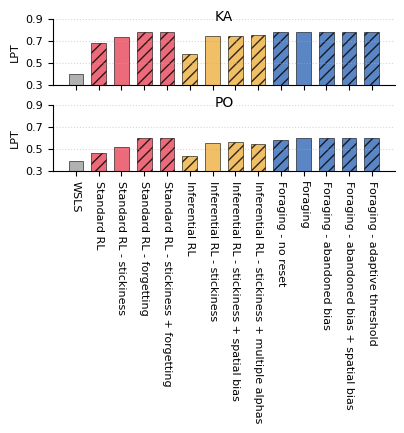

In [5]:

fig, ax = plot_res(res_all, paper_format=False)

# Adjust layout and save as SVG if needed
#plt.tight_layout()
# Uncomment the following line to save the figure
plt.savefig(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'figs', 'lpt.svg'), dpi=300, bbox_inches='tight', transparent=False)

plt.show()


LPT_CV: ka WSLS: 0.40
LPT_CV: ka Standard RL-noS: 0.68
LPT_CV: ka Inferential RL-noS: 0.58
LPT_CV: ka Standard RL: 0.74
LPT_CV: ka Inferential RL: 0.75
LPT_CV: ka Foraging: 0.79
LPT_CV: po WSLS: 0.39
LPT_CV: po Standard RL-noS: 0.47
LPT_CV: po Inferential RL-noS: 0.44
LPT_CV: po Standard RL: 0.52
LPT_CV: po Inferential RL: 0.56
LPT_CV: po Foraging: 0.60


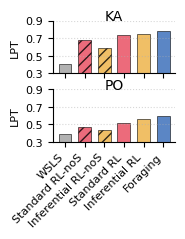

In [6]:
models_to_show = {
    'WSLS': 'WSLS',
    'Standard RL': 'Standard RL-noS',
    'Inferential RL': 'Inferential RL-noS',
    'Standard RL - stickiness': 'Standard RL',
    'Inferential RL - stickiness': 'Inferential RL',
    'Foraging': 'Foraging'
}

res_all_temp = res_all[res_all['Model'].isin(models_to_show.keys())].copy()
res_all_temp['Model'] = res_all_temp['Model'].map(models_to_show)
# sort in the order of models_to_show values, KA first and PO second
res_all_temp['Model'] = pd.Categorical(res_all_temp['Model'], categories=models_to_show.values(), ordered=True)
res_all_temp['monkey'] = pd.Categorical(res_all_temp['monkey'], categories=['ka', 'po'], ordered=True)
res_all_temp = res_all_temp.sort_values(['Model', 'monkey'])

fig, ax = plot_res(res_all_temp, paper_format=True)

# Adjust layout and save as SVG if needed
#plt.tight_layout()
# Uncomment the following line to save the figure
plt.savefig(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'figs', 'lpt_paper.svg'), dpi=300, bbox_inches='tight', transparent=False)

plt.show()


# Save best fit parameters to latex table (thesis + paper)

In [7]:
import re, sys
fname = 'bib.txt'
#fname = 'figs/lpt.png'
with open(fname, 'r') as f:
    text = f.read()
records = [r.strip() for r in re.split(r'\n\s*\n', text) if r.strip()]
deduped = sorted(set(records))  # sets remove duplicates; sort for stable output

# write back to file
with open(fname, 'w') as f:
    f.write('\n\n'.join(deduped))
    

FileNotFoundError: [Errno 2] No such file or directory: 'bib.txt'